In [7]:
from importlib import reload
import os
import numpy as np
import time
from tqdm import trange
from pulsestreamer import *
from nidaqmx import *

import analysis
reload(analysis)
from analysis import *

import measurement
reload(measurement)
from measurement import *

In [9]:
# loading the local Pulse Streamer and NIDAQmx
IPaddress = findPulseStreamers(search_serial='')[0][0]
pulser = PulseStreamer(IPaddress)

DAQ_device = nidaqmx.system.System.local().devices[0]
device_name = DAQ_device.terminals[0:1][0][1:5]
print(f'NIDAQmx device name : {device_name}')

Connect to Pulse Streamer via JSON-RPC.
IP / Hostname: 169.254.8.2
Pulse Streamer 8/2 firmware: v1.7.2
Client software: v1.7.0
NIDAQmx device name : Dev1


In [11]:
specs_ports = {'laserNum' : 1, 'gateStart' : 5, 'source' : 7}

specs_delay = {'rising_delay' : 2,'gatelen' :  6, 'laserontime' :  31,'delay_pad' :  2,
               'delay_shift' :  2,'gatesourcedelay' : 2}
specs_t1 = {'rising_delay' : 20,'gatelen' : 1.5e3, 'laserontime' : 25e3,'delay_pad' : 20,
            'delay_shift' : 50e3,'gatesourcedelay' : 5,'evolution_time' : 0.5e6}
specs_snr = {'rising_delay' : 20,'gatelen' : 1.5e3, 'laserontime' : 20e3,'delay_pad' : 20,
             'delay_shift' : (20e3-1.5e3)/10,'gatesourcedelay' : 5,'evolution_time' : 1.0e6}
specs_snr_new = {'rising_delay' : 20,'gatelen' : 1.5e3, 'laserontime' : 20e3,'delay_pad' : 20,
             'delay_shift' : (20e3-1.5e3)/10,'gatesourcedelay' : 5,'evolution_time' : 1e6}

specs_lifetime = {'rising_delay' : 2,'gatelen' : 2, 'laserontime' : 25,'laserofftime' : 50,
                  'delay_pad' : 2,'delay_shift' : 2,'gatesourcedelay' : 2}  
specs_t1_ir = {'rising_delay' : 20,'gatelen' : 2e3, 'laserontime' : 25e3,'delay_pad' : 20,
            'delay_shift' : 45e3,'gatesourcedelay' : 5,'evolution_time' : 0.45e6,'irontime' : 1e3,'irport' : 3}
specs_t1_simple = {'rising_delay' : 10,'gatelen' : 3e3, 'laserontime' : 1000e3,'delay_pad' : 10,
            'delay_shift' : 30e3,'gatesourcedelay' : 5,'evolution_time' : 0.30e6,'first_time': 5e3}
specs_t1_new = {'rising_delay' : 20,'gatelen' : 0.5e3, 'laserontime' : 1000e3,'delay_pad' : 20,
            'delay_shift' : 35e3,'gatesourcedelay' : 5,'evolution_time' : 0.35e6}

In [37]:
# experiment specifications
exp_name = "t1_simple"  # write the exp_name from previous cell without the first "specs_" part 
samples = 2000
averages = 5
first_sig_ref = "signal"  # depends on the sequence 


# inside folder and file names : remember to keep 
inside_folders=["MD",f"{exp_name}","525_9mW","without_UCP","3rd_cluster", f'laser_{globals()["specs_"+exp_name]["laserontime"]}']  # last one is laser duration
file_name=f'{globals()["specs_"+exp_name]["gatelen"]}' # counter duration

In [39]:
total_specs = merge(specs_ports,globals()["specs_"+exp_name])

In [41]:
# plot_sequence(pulser=pulser,exp_name='t1_new',specifications=total_specs)
# get_time(pulser=pulser,exp_name='t1_new',specifications=total_specs)

In [43]:
avg_data,time_axis = measure(pulser,DAQ_device,device_name,exp_name = exp_name,
                   samples=samples,averages=averages,specifications=total_specs)

number of steps : 10
Pixel : 20000
creating sequence
starting DAQ
Preparing NiDaq for the experiment
callback number in beginning: 0


  0%|          | 0/5 [00:00<?, ?it/s]

1
2
3
4
5
6
7
8
9
10


 20%|██        | 1/5 [00:31<02:07, 31.76s/it]

callback number after 1-th average end: 10
1
2
3
4
5
6
7
8
9
10


...

callback number after 3-th average end: 30
1
2
3
4
5
6
7
8
9
10


 80%|████████  | 4/5 [02:07<00:31, 31.75s/it]

callback number after 4-th average end: 40
1
2
3
4
5
6
7
8
9
10


100%|██████████| 5/5 [02:38<00:00, 31.75s/it]

callback number after 5-th average end: 50
Total Run : 50
Total Counts & Counts in one average : (100000, 20000)
Crosscheck number of averges= 5
returning averaged counts and time_axis


In [45]:
dict_args = {'avg_data':avg_data,'time_axis':time_axis}

In [47]:
root_directory = os.getcwd()
print(f'root directory : {root_directory}')

root directory : C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes


In [65]:
year = time.ctime()[-4:]
date = time.ctime()[4:10].replace(' ','_')
current_time = time.ctime()[-13:-8].replace(':','_')

# # folder_path = root_directory+f'/exp_data/{year}/{date}/microdiamonds/t1_simple/525nm/with_Gd_FeUCP/0.1M_15%/avgs_5/samples_2000/laser_1000e3/'
# folder_path = root_directory+f'/exp_data/{year}/{date}/microdiamonds/{exp_name}/525nm/with_Gd_FeUCP/0.1M_15%/avgs_{averages}/samples_{samples}/laser_{globals()['specs_'+exp_name]['laserontime']}/'
# file_name = f'[{current_time}]_gate_{globals()['specs_'+exp_name]['gatelen']}.npz'

initial_path = os.path.join(root_directory, f'data/{year}/{date}')
inside_path = os.path.join(initial_path, *inside_folders)
full_path = os.path.join(inside_path, f'a_{averages}', f's_{samples}', f'l_{globals()["specs_"+exp_name]["laserontime"]}')
os.makedirs(full_path, exist_ok=True)

file_name = f'[{current_time}]_g_{globals()["specs_"+exp_name]["gatelen"]}.npz'

try:
    total_path = npz_save(full_path,file_name,**dict_args)
except Exception as e:
    print(f"An error occurred: \n{e}")
    print("\nPlease reduce the folder_name")

An error occurred: 
name 'npz_save' is not defined

Please reduce the folder_name


In [22]:
load_data = dict(np.load(total_path))

NameError: name 'total_path' is not defined

In [48]:
time_axis,signal_photon,reference_samples,signal_samples = data_to_time_signal(avg_data,samples,first=first_sig_ref)

ValueError: not enough values to unpack (expected 4, got 3)

In [49]:
signal_photon,reference_samples,signal_samples = signal(avg_data,samples,first='reference')
signal_photon,time_axis

(array([0.02448488, 1.03829391, 1.02137665, 1.0187674 , 1.01208154,
        1.01285429, 1.00761165, 1.00443124, 1.0069273 , 1.00299124]),
 array([    20,  35020,  70020, 105020, 140020, 175020, 210020, 245020,
        280020, 315020]))

co-efficients are : [1.00392852e+00 5.13643346e-02 7.86739906e+04] 
with corresponding errorbars: [2.16552102e-03 5.93746838e-03 1.78090981e+04]

Lifetime in nano_second is : 78674.0 ± 17809.1



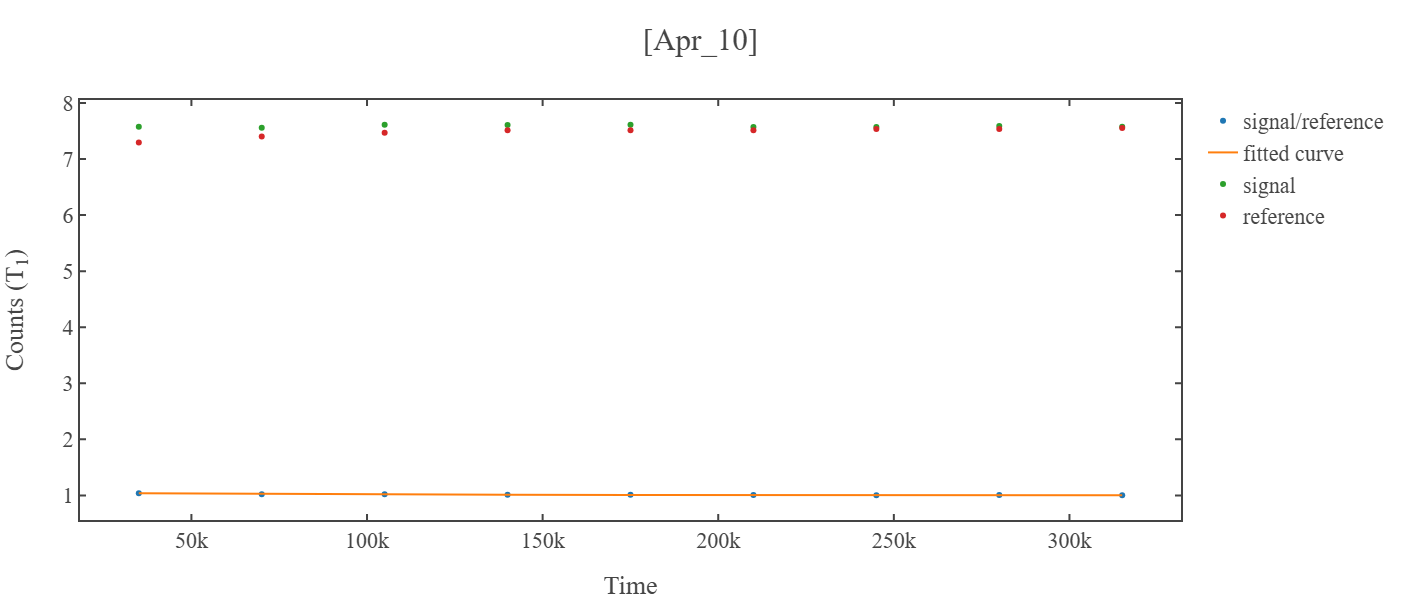

In [51]:
x=time_axis[1:]
y=signal_photon[1:]

x_fit,y_fit,coefficient,error_bars = fit_func(x,y,fit_range=False,func='exp',guess_params=np.array([0.7,1,0.5e6]))

fig1 = simple_plot(x,y,show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='markers',title=f'{date}',curve_name='signal/reference')
fig2 = simple_plot(x_fit,y_fit,show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='lines',title=f'{date}',curve_name='fitted curve')
fig3 = simple_plot(x,signal_samples[1:],show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='markers',title=f'{date}',curve_name='signal')
fig4 = simple_plot(x,reference_samples[1:],show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='markers',title=f'{date}',curve_name='reference')

add_figures([fig1,fig2,fig3,fig4],show=True,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",title=f'[{date}]')

## Add calibrations, specifications and few reference plots

10th April, 2025

for calibration 
laser power = 4mW (source), uW(sample plane)
count =  63k/sec (bin width = 10ms, no. of bins = 1000) from emission (with 650nm LP filter)

experiment performed 
laser power = 17mW. 